# 🦒 Fine-tuning Cellpose with BioEngine ⚙️☁️

## Installation and module imports

In [1]:
try:
    # For pyodide in the browser
    import micropip

    await micropip.install(["pyodide-http", "hypha-rpc", "httpx", "kaibu-utils", "matplotlib", "tifffile", "numpy"])

    # 2. Patch requests
    import pyodide_http

    pyodide_http.patch_all()  # Patch all libraries
except ImportError:
    # For native python with pip
    import subprocess

    subprocess.call(["pip", "install", "hypha-rpc", "httpx", "kaibu-utils", "matplotlib", "tifffile", "numpy"])

import zipfile
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
from hypha_rpc import connect_to_server, login
from tifffile import imread

In [2]:
# Server URL: For this demo we will use the hypha.aicell.io server
SERVER_URL = "https://hypha.aicell.io"

### Connect to the server

In [3]:
import os

# Use HYPHA_TOKEN from environment if available (for automated execution)
# otherwise fall back to interactive browser login
if os.environ.get("HYPHA_TOKEN"):
    token = os.environ["HYPHA_TOKEN"]
else:
    token = await login({"server_url": SERVER_URL})

server = await connect_to_server(
    {"server_url": SERVER_URL, "token": token}
)
workspace = server.config.workspace

print(f"Connected to workspace: {workspace}")

artifact_manager = await server.get_service("public/artifact-manager")

Connected to workspace: ws-user-github|478667


### Access the BioEngine deployments

A public BioEngine instance is available with the service ID `bioimage-io/bioengine-apps`

In [4]:
PUBLIC_BIOENGINE = "bioimage-io/bioengine-apps"

try:
    bioengine = await server.get_service(PUBLIC_BIOENGINE)
    print(f"Connected to public BioEngine service: {PUBLIC_BIOENGINE}")
except Exception:
    print(f"Public BioEngine service not available, will use cellpose-finetuning service directly.")
    bioengine = None

Public BioEngine service not available, will use cellpose-finetuning service directly.


If you have started your own BioEngine instance, you can first list your deployment services and then 

In [5]:
services = await server.list_services({"type": "bioengine-apps"})

for service in services:
    print(f"BioEngine apps service ID: {service.id}")
    PRIVATE_BIOENGINE = service.id

if len(services) == 0:
    print(f"No BioEngine apps service available in workspace '{server.config.workspace}'.")

bioengine = await server.get_service(PRIVATE_BIOENGINE)

BioEngine apps service ID: ws-user-github|478667/bRTvZB5ENH7rRo7ALRyfJe-qvgkx08x:shiny-moon-bdbf


### Visualize some collected data

In [6]:
# We use an existing annotated dataset from the BioImage.IO collection.
# This artifact contains HPA cell images with mask annotations.
data_artifact_id = "bioimage-io/annotation-mnw8359y-ehab"
workspace_part, data_artifact_alias = data_artifact_id.split("/", 1)

# Download a few example images locally for visualization
import tempfile, httpx, asyncio
data_dir = Path(tempfile.mkdtemp(prefix="hpa_demo_"))
print(f"Using artifact: {data_artifact_id}")
print(f"Downloading sample images to: {data_dir}")

Using artifact: bioimage-io/annotation-mnw8359y-ehab


In [7]:
# Fetch file listing and download sample image-mask pairs for visualization
import httpx

async def download_artifact_file(am, artifact_id, remote_path, local_path):
    url = await am.get_file(artifact_id, file_path=remote_path)
    async with httpx.AsyncClient(timeout=60) as client:
        r = await client.get(url)
        r.raise_for_status()
        local_path.write_bytes(r.content)

train_files = await artifact_manager.list_files(data_artifact_id, dir_path="train_images")
mask_files  = await artifact_manager.list_files(data_artifact_id, dir_path="masks_cells")

# Only keep PNG masks (exclude geojson)
train_names = sorted(f["name"] for f in train_files if f["name"].endswith(".png"))
mask_names  = sorted(f["name"] for f in mask_files  if f["name"].endswith(".png"))

# Build paired list (match by stem)
mask_by_stem = {Path(m).stem: m for m in mask_names}
image_annotation_pairs = [
    (f"train_images/{t}", f"masks_cells/{mask_by_stem[Path(t).stem]}")
    for t in train_names
    if Path(t).stem in mask_by_stem
]
print(f"Found {len(image_annotation_pairs)} image-mask pairs in artifact")

# Download first 5 for local visualization
sample_pairs = image_annotation_pairs[:5]
(data_dir / "train_images").mkdir(parents=True, exist_ok=True)
(data_dir / "masks_cells").mkdir(parents=True, exist_ok=True)

for img_path, mask_path in sample_pairs:
    await download_artifact_file(artifact_manager, data_artifact_id, img_path, data_dir / img_path)
    await download_artifact_file(artifact_manager, data_artifact_id, mask_path, data_dir / mask_path)

image_annotation_pairs_local = [
    (data_dir / img, data_dir / mask)
    for img, mask in sample_pairs
]
print(f"Downloaded {len(image_annotation_pairs_local)} pairs for visualization")

Found 13 image-mask pairs in artifact


Downloaded 5 pairs for visualization


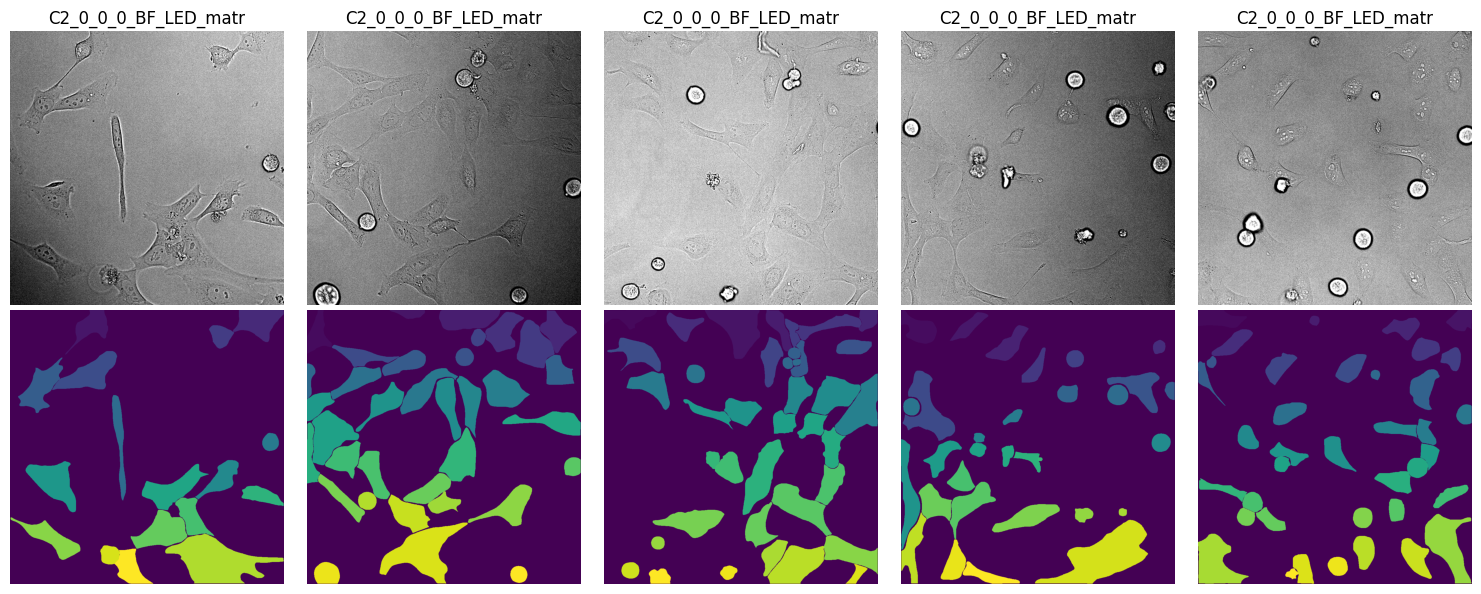

In [8]:
from PIL import Image
import numpy as np

assert len(image_annotation_pairs_local) >= 5

# Plot several annotations
plt.figure(figsize=(15, 6))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    img = np.array(Image.open(image_annotation_pairs_local[i][0]))
    plt.imshow(img)
    plt.title(image_annotation_pairs_local[i][0].stem[:20])
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    mask = np.array(Image.open(image_annotation_pairs_local[i][1]))
    plt.imshow(mask)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Use the existing annotated dataset

The dataset is already available in the BioImage.IO Colab collection as `bioimage-io/annotation-mnw8359y-ehab`.
We will use it directly for training without re-uploading.

In [9]:
# The dataset artifact is already available — use it directly for training
print(f"Using existing dataset artifact: {data_artifact_id}")
print(f"Artifact alias: {data_artifact_alias}")

Using existing dataset artifact: bioimage-io/annotation-mnw8359y-ehab
Artifact alias: annotation-mnw8359y-ehab


In [10]:
# Dataset already uploaded — skipping re-upload step

In [11]:
# (skipped)

In [12]:
# (skipped)

In [13]:
# data_artifact_alias already set above

### Choose a pre-trained model to fine-tune

**Note:** Cellpose 4.0.7 only supports the `cpsam` (Cellpose-SAM) model. This is a transformer-based segmentation model that is channel-order invariant and provides better performance than previous versions.

In [14]:
# Only Cellpose-SAM (cpsam) is supported in Cellpose 4.0.7
pretrained_models = ["cpsam"]
print("Available pretrained models: \n -", '\n - '.join(pretrained_models))

Available pretrained models: 
 - cpsam


Here we choose the `cellpose` model `cpsam` (Cellpose-SAM 4.0) for segmentation.

**Note:** Cellpose 4.0.7 only supports the `cpsam` model, which is a transformer-based model that is channel-order invariant.

In [15]:
initial_model = "cpsam"

### Start the fine-tuning

We pass the dataset artifact ID directly to `start_training()`. Training uses glob patterns to find
images and masks inside the artifact. No manual zip upload or presigned URL creation is needed.

In [16]:
# Confirm the dataset artifact we will train on
print(f"Training dataset : {data_artifact_id}")
print(f"  - train images : train_images/*.png")
print(f"  - train masks  : masks_cells/*.png")

Training dataset : bioimage-io/annotation-mnw8359y-ehab
  - train images : train_images/*.png
  - train masks  : masks_cells/*.png


### Run the Cellpose fine-tuning with Real-Time Progress Tracking

The async API allows you to start training and monitor its progress with comprehensive real-time updates. 

**Key Features:**
- **Real-time epoch tracking**: See current epoch, total epochs, and progress
- **Training metrics**: Monitor training and test losses as they update
- **Dataset information**: View training/test sample counts immediately
- **Timing information**: Track elapsed time and training start time
- **Path-based file matching**: Use wildcard patterns to match image/annotation files

**Parameters:**
- `artifact`: Your training dataset artifact ID
- `train_images`: Path pattern for training images (e.g., "*.tif", "images/*.ome.tif")
- `train_annotations`: Path pattern for annotations (e.g., "annotations/*_mask.tif")
- `test_images`, `test_annotations`: Optional test set patterns
- `model`: Pretrained model to start from (default: "cpsam")
- `n_epochs`: Number of training epochs
- `n_samples`: Optional - limit number of samples to use

**The API will:**
1. Start training asynchronously and return a session ID
2. Provide real-time status updates via `get_training_status(session_id)`
3. Track comprehensive metrics: losses, timing, dataset info, epoch progress
4. When complete, use the session ID as the model parameter for inference

**Enhanced Status Information:**
The status now includes: `status_type`, `message`, `train_losses`, `test_losses`, `n_train`, `n_test`, `start_time`, `current_epoch`, `total_epochs`, and `elapsed_seconds` - giving you complete visibility into training progress!

In [17]:
# Start the Cellpose fine-tuning asynchronously
import asyncio

# Get the cellpose service
cellpose_service = await server.get_service("bioimage-io/cellpose-finetuning")

# Start training with path patterns matching the artifact structure
session_status = await cellpose_service.start_training(
    artifact=data_artifact_id,
    train_images="train_images/*.png",
    train_annotations="masks_cells/*.png",
    model=initial_model,
    n_epochs=10,
    n_samples=None,  # Use all available samples
    min_train_masks=1,
)

session_id = session_status["session_id"]
print(f"Training session started with ID: {session_id}")
print(f"  start_time: {session_status.get('start_time')}")
print()
print("Monitoring training progress with real-time updates...\n")

# Monitor training progress
while True:
    status = await cellpose_service.get_training_status(session_id)
    st = status['status_type']
    msg = f"[{st}] {status['message']}"
    if "n_train" in status:
        msg += f" | Train: {status['n_train']} samples"
    if "current_epoch" in status and "total_epochs" in status:
        msg += f" | Epoch: {status['current_epoch']}/{status['total_epochs']}"
    if "elapsed_seconds" in status:
        msg += f" | Time: {status['elapsed_seconds']:.1f}s"
    if status.get("train_losses"):
        losses = [l for l in status["train_losses"] if l > 0]
        if losses:
            msg += f" | Train Loss: {losses[-1]:.4f}"
    print(f"\r{msg}", end="", flush=True)
    if st in ("completed", "failed"):
        print("\n")
        break
    await asyncio.sleep(2)

if status["status_type"] == "failed":
    raise RuntimeError(f"Training failed: {status['message']}")

print("=" * 80)
print("Training Completed Successfully!")
print("=" * 80)
print(f"Fine-tuned model session ID: {session_id}")

if status.get("train_losses"):
    valid_losses = [l for l in status["train_losses"] if l > 0]
    if valid_losses:
        print(f"Initial loss: {valid_losses[0]:.4f}")
        print(f"Final loss: {valid_losses[-1]:.4f}")
        print(f"Loss improvement: {((valid_losses[0] - valid_losses[-1]) / valid_losses[0] * 100):.1f}%")

Training session started with ID: 2026-04-13-130035-b2685ee0
  start_time: None

Monitoring training progress with real-time updates...

[preparing] Listing files and matching training pairs from artifact...

[preparing] Loading Cellpose model...

[running] Training started (epoch 0/10) | Train: 13 samples | Epoch: 0/10 | Time: 0.0s

[running] Training epoch 1/10 (batch 1/13) | Train: 13 samples | Epoch: 1/10 | Time: 0.6s

[running] Training epoch 1/10 (batch 1/13) | Train: 13 samples | Epoch: 1/10 | Time: 0.6s

...

[running] Training epoch 10/10 (batch 1/13) | Train: 13 samples | Epoch: 10/10 | Time: 78.4s | Train Loss: 1.6690

[running] Training epoch 10/10 (batch 11/13) | Train: 13 samples | Epoch: 10/10 | Time: 83.7s | Train Loss: 1.6690

[running] Training in progress (epoch 10/10) | Train: 13 samples | Epoch: 10/10 | Time: 84.8s | Train Loss: 1.6994

[completed] Training completed successfully | Train: 13 samples | Epoch: 10/10 | Time: 89.3s | Train Loss: 1.6994



Training Completed Successfully!
Fine-tuned model session ID: 2026-04-13-130035-b2685ee0
Initial loss: 1.4655
Final loss: 1.6994
Loss improvement: -16.0%


### Test the fine-tuned model

Now let's test the fine-tuned model by running inference on a sample image.

In [18]:
# Run inference with the fine-tuned model
# We already have the images downloaded locally — pass them as input_arrays.
# We crop to 256×256 to keep inference time fast (~4 s).
from PIL import Image

test_img_np = np.array(Image.open(image_annotation_pairs_local[0][0]))  # HWC
crop_size = 256
test_img_np = test_img_np[:crop_size, :crop_size]                       # crop
test_img_chw = test_img_np.transpose(2, 0, 1)                           # → CHW

inference_result = await cellpose_service.infer(
    model=session_id,  # Use the fine-tuned model
    input_arrays=[test_img_chw],
    diameter=40,
)

print(f"Inference completed!")
print(f"Result shape: {inference_result[0]['output'].shape}")


Inference completed!
Result shape: (256, 256)


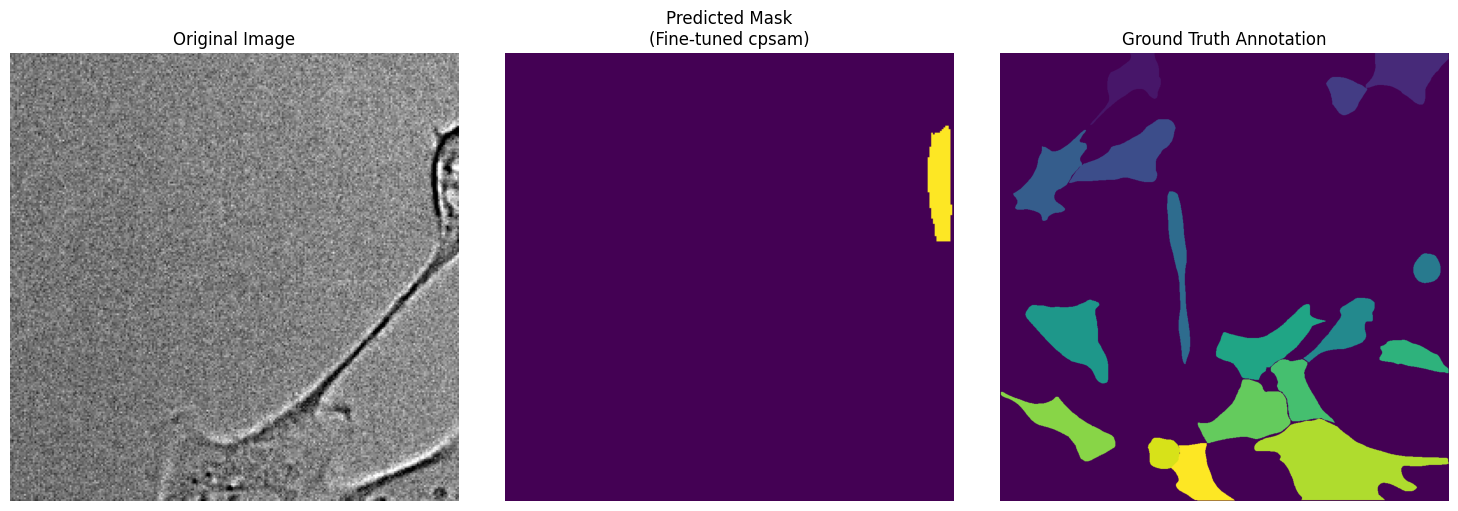

In [19]:
# Visualize the inference result
test_mask = np.array(Image.open(image_annotation_pairs_local[0][1]))
predicted_mask = inference_result[0]['output']

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(test_img_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(predicted_mask)
plt.title(f"Predicted Mask\n(Fine-tuned {initial_model})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(test_mask)
plt.title("Ground Truth Annotation")
plt.axis("off")

plt.tight_layout()
plt.show()


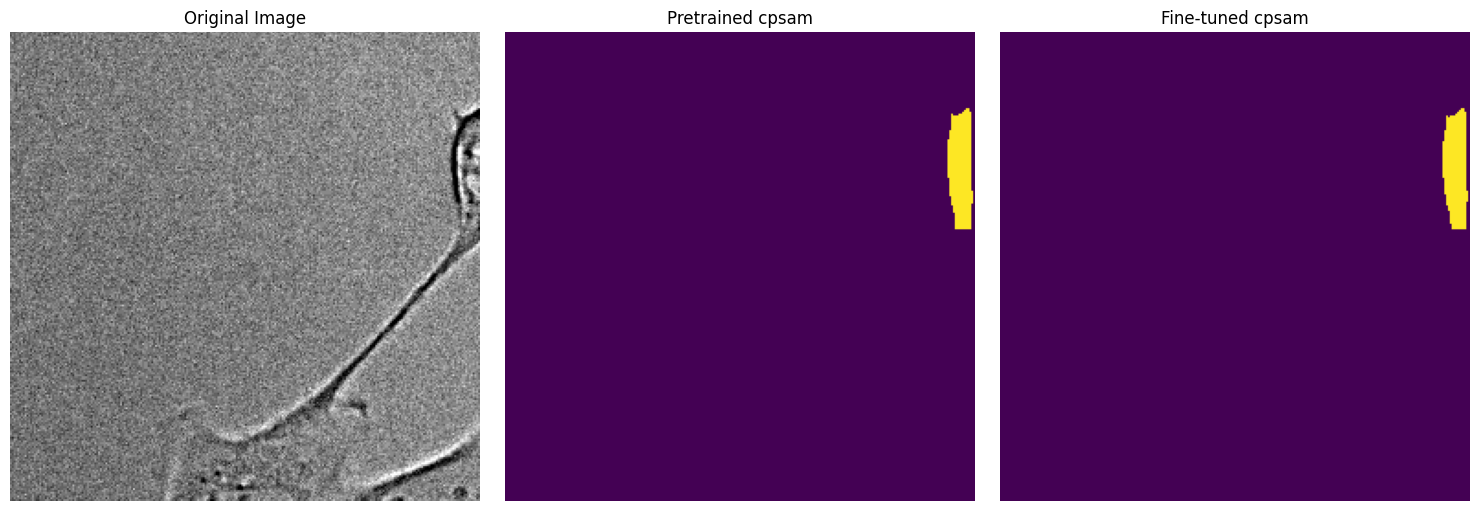


Comparison complete!
You can see how the fine-tuned model performs compared to the pretrained model.


In [20]:
# Compare with pretrained model (same image, using input_arrays)
pretrained_result = await cellpose_service.infer(
    model=initial_model,
    input_arrays=[test_img_chw],
    diameter=40,
)

pretrained_mask = pretrained_result[0]['output']

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(test_img_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pretrained_mask)
plt.title(f"Pretrained {initial_model}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(inference_result[0]['output'])
plt.title(f"Fine-tuned {initial_model}")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"\nComparison complete!")
print(f"You can see how the fine-tuned model performs compared to the pretrained model.")


### Export the fine-tuned model

Once training is complete, you can export the model as a BioImage.IO artifact. The exported model:
- Is stored in the `bioimage-io/colab-annotations` collection
- Can be used directly for inference by passing the `artifact_id` as the `model` argument to `infer()`
- Can be used as the starting point for further fine-tuning by passing the `artifact_id` as the `model` argument to `start_training()`

Note: Training sessions can be deleted via the `delete_training_session()` API, but published model artifacts are permanent and cannot be removed through this application.

In [21]:
# Export the fine-tuned model as a BioImage.IO artifact
import datetime
ts = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

export_result = await cellpose_service.export_model(
    session_id=session_id,
    model_name=f"cellpose-finetuned-tutorial-{ts}",
    description="Cellpose-SAM model fine-tuned on HPA demo dataset via the BioEngine tutorial.",
)

exported_artifact_id = export_result["artifact_id"]
print(f"Model exported successfully!")
print(f"  Artifact ID : {exported_artifact_id}")
print(f"  Artifact URL: {export_result['artifact_url']}")
print(f"  Download ZIP: {export_result['download_url']}")


Model exported successfully!
  Artifact ID : bioimage-io/cellpose-finetuned-tutorial-20260413-150222
  Artifact URL: https://hypha.aicell.io/bioimage-io/artifacts/cellpose-finetuned-tutorial-20260413-150222
  Download ZIP: https://hypha.aicell.io/bioimage-io/artifacts/cellpose-finetuned-tutorial-20260413-150222/create-zip-file


### Continue fine-tuning from the exported model

You can resume or continue fine-tuning from any previously exported model artifact by passing its `artifact_id` as the `model` parameter. This lets you iteratively improve a model across multiple training runs.

In [22]:
# Start a new training session using the exported model as the starting point
session_status_continued = await cellpose_service.start_training(
    artifact=data_artifact_id,
    train_images="train_images/*.png",
    train_annotations="masks_cells/*.png",
    model=exported_artifact_id,  # Use the exported model as starting point
    n_epochs=5,
    min_train_masks=1,
)

session_id_continued = session_status_continued["session_id"]
print(f"Continued training session started: {session_id_continued}")
print(f"  last_continued_time: {session_status_continued.get('last_continued_time')}")
print()

# Monitor progress
while True:
    status = await cellpose_service.get_training_status(session_id_continued)
    st = status["status_type"]
    msg = f"[{st}] {status['message']}"
    if "current_epoch" in status and "total_epochs" in status:
        msg += f" | Epoch: {status['current_epoch']}/{status['total_epochs']}"
    if status.get("train_losses"):
        msg += f" | Loss: {status['train_losses'][-1]:.4f}"
    print(f"\r{msg}", end="", flush=True)
    if st in ("completed", "failed", "stopped"):
        print()
        break
    await asyncio.sleep(2)

if status["status_type"] == "failed":
    raise RuntimeError(f"Continued training failed: {status['message']}")
print(f"Continued training completed!")


Continued training session started: 2026-04-13-130320-a689044c
  last_continued_time: None

[preparing] Listing files and matching training pairs from artifact...

[preparing] Loading Cellpose model...

[running] Training started (epoch 0/5) | Epoch: 0/5

[running] Training epoch 1/5 (batch 1/13) | Epoch: 1/5 | Loss: 0.0000

[running] Training epoch 1/5 (batch 1/13) | Epoch: 1/5 | Loss: 0.0000

...

[running] Training epoch 5/5 (batch 1/13) | Epoch: 5/5 | Loss: 2.4349

[running] Training epoch 5/5 (batch 11/13) | Epoch: 5/5 | Loss: 2.4349

[running] Training in progress (epoch 5/5) | Epoch: 5/5 | Loss: 1.2899

[completed] Training completed successfully | Epoch: 5/5 | Loss: 1.2899


Continued training completed!


### Delete training sessions

Training sessions can be deleted using `delete_training_session()`. Only the session owner can delete their own sessions.

**Note:** This only deletes the local training session (model weights, logs, status). The exported model artifact (`exported_artifact_id`) is published to BioImage.IO and is not affected.

In [23]:
# Delete the continued training session
delete_result = await cellpose_service.delete_training_session(session_id=session_id_continued)
print(f"Deleted continued session: {delete_result['deleted']}")

# Delete the original training session
delete_result_orig = await cellpose_service.delete_training_session(session_id=session_id)
print(f"Deleted original session:  {delete_result_orig['deleted']}")

print()
print(f"The exported model artifact is still available at:")
print(f"  {export_result['artifact_url']}")


Deleted continued session: 2026-04-13-130320-a689044c
Deleted original session:  2026-04-13-130035-b2685ee0

The exported model artifact is still available at:
  https://hypha.aicell.io/bioimage-io/artifacts/cellpose-finetuned-tutorial-20260413-150222


In [24]:
# Additional notes about the API

print("""
### Cellpose Fine-Tuning API Summary (with Real-Time Progress Tracking)

The async API provides the following methods:

1. start_training() - Start asynchronous fine-tuning
   Parameters:
   - artifact: Artifact ID containing training data
   - train_images: Path pattern for training images (e.g., "*.tif" or "images/*.ome.tif")
   - train_annotations: Path pattern for annotations (e.g., "annotations/*_mask.tif")
   - test_images: Optional test images path pattern
   - test_annotations: Optional test annotations path pattern
   - model: Pretrained model to start from (default: "cpsam")
   - n_epochs: Number of training epochs
   - n_samples: Number of samples to use (optional)
   - learning_rate, weight_decay: Training hyperparameters
   
2. get_training_status(session_id) - Monitor training progress with real-time updates
   Returns comprehensive status dict with:
   - status_type: "waiting", "preparing", "running", "completed", or "failed"
   - message: Human-readable status message
   - train_losses: Per-epoch training loss values (updated in real-time)
   - test_losses: Per-epoch test loss values (computed periodically)
   - n_train: Number of training samples
   - n_test: Number of test samples
   - start_time: Training start time (ISO 8601 format)
   - current_epoch: Current epoch number (1-indexed)
   - total_epochs: Total number of epochs
   - elapsed_seconds: Elapsed time since training started
   
3. infer() - Run inference with a model
   Parameters:
   - model: Model ID (session_id for fine-tuned, or "cpsam" for pretrained)
   - artifact: Artifact ID containing images
   - image_paths: List of image paths within the artifact
   - diameter: Expected cell diameter (optional, auto-detected if None)
   - flow_threshold: Flow error threshold (default: 0.4)
   - cellprob_threshold: Cell probability threshold (default: 0.0)
   - niter: Number of iterations for dynamics (default: None, auto-set)
   
4. list_pretrained_models() - Get available pretrained models
   
### Key Features:
- Real-time progress tracking with epoch-by-epoch updates
- Comprehensive training metrics including losses, timing, and dataset info
- Path-based training API with wildcard patterns for flexible file matching
- Cellpose-SAM is channel-order invariant - no need to specify channel order
- Automatically uses first 3 channels of your image
- For best results, use flow_threshold=0.4, cellprob_threshold=0, niter=250
""")


### Cellpose Fine-Tuning API Summary (with Real-Time Progress Tracking)

The async API provides the following methods:

1. start_training() - Start asynchronous fine-tuning
   Parameters:
   - artifact: Artifact ID containing training data
   - train_images: Path pattern for training images (e.g., "*.tif" or "images/*.ome.tif")
   - train_annotations: Path pattern for annotations (e.g., "annotations/*_mask.tif")
   - test_images: Optional test images path pattern
   - test_annotations: Optional test annotations path pattern
   - model: Pretrained model to start from (default: "cpsam")
   - n_epochs: Number of training epochs
   - n_samples: Number of samples to use (optional)
   - learning_rate, weight_decay: Training hyperparameters

2. get_training_status(session_id) - Monitor training progress with real-time updates
   Returns comprehensive status dict with:
   - status_type: "waiting", "preparing", "running", "completed", or "failed"
   - message: Human-readable status message
   